In [ ]:
# !pip install rapidfuzz sentence-transformers bertopic nltk

In [1]:
import os
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm
from rapidfuzz import fuzz, utils
from datasets import load_dataset, load_from_disk, Dataset

In [2]:
DATA_PATH = "./data"
os.makedirs(DATA_PATH, exist_ok=True)

# Data preprocessing

**[WildChat-1M](https://huggingface.co/datasets/allenai/WildChat-1M) dataset — 1M ChatGPT Interaction Logs in the Wild**

In [3]:
ds = load_dataset("allenai/WildChat-1M")["train"]

Extract sessions in Russian:

In [4]:
ds = ds.filter(lambda example: example["language"] == "Russian")
print(len(ds))
# ds.save_to_disk(f"{DATA_PATH}/wildchat-ru")
# ds = load_from_disk(f"{DATA_PATH}/wildchat-ru")

87127


Model distribution:

In [5]:
Counter([conv["model"] for conv in ds])

Counter({'gpt-3.5-turbo-0613': 34204,
         'gpt-3.5-turbo-0301': 24412,
         'gpt-4-1106-preview': 13030,
         'gpt-4-0125-preview': 7408,
         'gpt-4-0314': 4520,
         'gpt-3.5-turbo-0125': 3552,
         'gpt-4-0613': 1})

Deduplicate by `conversation_hash` provided in annotation:

In [6]:
df = pd.DataFrame(ds)
print(len(df))
df = df.drop_duplicates("conversation_hash")
ds = Dataset.from_pandas(df)
print(len(ds))

87127
86571


Remove duplicates inside sessions:

In [7]:
def normalize_text(text: str) -> str:
    return text.lower().strip()

def is_duplicate(text1: str, text2: str, threshold: int = 100) -> bool:
    return fuzz.ratio(
        normalize_text(text1),
        normalize_text(text2), 
        processor=utils.default_process
    ) >= threshold

def extract_user_turns_no_duplicates(example, duplicate_threshold: int = 95):
    session_id = example["conversation_hash"]
    user_turns = []
    seen_texts = []

    for i, turn in enumerate(example["conversation"]):
        if turn["role"] != "user":
            continue

        content = turn["content"]
        if not content or not isinstance(content, str):
            continue

        is_dup = any(is_duplicate(content, seen, duplicate_threshold) for seen in seen_texts)
        if is_dup:
            continue

        if turn.get("toxic", False) or any(example["openai_moderation"][i]["categories"].values()):
            continue

        seen_texts.append(content)

        if content.count(" ") > 2:
            user_turns.append({
                "session_id": session_id,
                "turn_index": i,
                "prompt": content,
            })

    return {"user_turns": user_turns}

In [8]:
processed_sessions = ds.map(
    extract_user_turns_no_duplicates,
    remove_columns=ds.column_names,
    desc="Extracting user-subsessions without duplicates",
)

Extracting user-subsessions without duplicates:   0%|          | 0/86571 [00:00<?, ? examples/s]

In [9]:
all_turns = []
for session in tqdm(processed_sessions["user_turns"], desc="Flattening"):
    all_turns.extend(session)

print(len(all_turns))

df = pd.DataFrame(all_turns)
df.sample(5)

Flattening: 100%|██████████| 86571/86571 [00:00<00:00, 3928773.36it/s]


203339


,prompt,session_id,turn_index
27932,"Great deeds live. \nЧалавек жыве век, а добрае...",24b7a1a9fbb7777a00fed34bb2a00944,2
142604,Теория: «Пегас Туристик» является одним из кру...,deb6829f9a9546ee2974e85df66b346a,0
127007,почему нужно украшать дом к новому году?,b7392886863ec620bfe4d6e34627296d,0
19868,Каталитический реформинг плюс и минусы,58f0b5ce3a68573d48e9fe5b3cb45e77,0
57617,"переформулировать текст: Тела, отнесенные к ка...",2231511be5a30835ccb990a313d16c34,24


In [10]:
# proxy to count words as the number of whitespaces + 1
df["word_count"] = df.prompt.apply(lambda x: x.count(" ") + 1)
df["word_count"].describe()

count    203339.000000
mean         83.961547
std        1093.177520
min           4.000000
25%           8.000000
50%          14.000000
75%          37.000000
max      265319.000000
Name: word_count, dtype: float64

<Axes: >

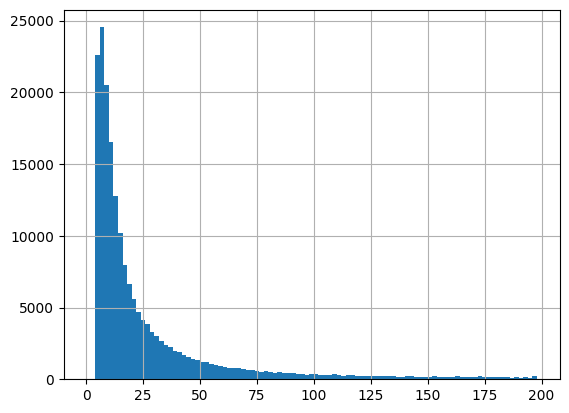

In [11]:
df["word_count"].hist(bins=range(0, 200, 2))

In [12]:
df = df[df.word_count < 200].copy()
len(df)

190115

Remove duplicates among sessions:

In [13]:
def normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def hash_first_last_200_chars(text: str) -> str:
    normalized_text = normalize(text[:200] + text[-200:])
    return hash(normalized_text.encode())

df["hash"] = df["prompt"].apply(hash_first_last_200_chars)

df_dedup = df.drop_duplicates(subset=["hash"]).reset_index(drop=True)
len(df_dedup)

181836

In [14]:
df_dedup.to_csv(f"{DATA_PATH}/wildchat_ru_filtered_dedup.csv")
# df = pd.read_csv(f"{DATA_PATH}/wildchat_ru_filtered_dedup.csv", index_col=0)

# Prompt clustering

In [17]:
# sample = df.sample(30000, random_state=43)

# load sample df from file

sample = pd.read_csv(f"{DATA_PATH}/wildchat_ru_actions_multi.csv")
len(sample)

prompt_to_action = {}
for i, row in sample.iterrows():
    prompt_to_action[row["prompt"]] = row["action"]

## Prepare embeddings

### Basic embeddings

We use `intfloat/multilingual-e5-large-instruct` as the embedding model.

It is recommended in the model card to prepend both inputs with `"query: "` prefix for semantic similary task.

In [18]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("intfloat/multilingual-e5-large-instruct")

In [19]:
# Compute embeddings for unique prompts
unique_prompts = sample["prompt"].unique()
formatted_prompts = [f"query: {prompt}" for prompt in unique_prompts]
prompt_embeddings = embedding_model.encode(formatted_prompts, show_progress_bar=True)

# Save embeddings into a dictionary
prompt_to_embedding = dict(zip(unique_prompts, prompt_embeddings))

# Map embeddings back into the DataFrame
sample["emb_prompt"] = sample["prompt"].map(prompt_to_embedding)

Batches:   0%|          | 0/937 [00:00<?, ?it/s]

In [74]:
random_sample = sample.sample()
random_sample

,Unnamed: 0,prompt,session_id,turn_index,word_count,hash,action,emb_prompt
22121,134161,а теперь напиши какая проблема исследования,dab461c16697b0c5326d11b9137fda14,6,6,-7856569256606020768,['НЕТ ИНСТРУКЦИИ'],"[0.018074622, -0.012186844, -0.025609849, -0.0..."


Check top-5 prompts closest by embedding cosine similarity:

In [75]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query_id = random_sample.index[0]
query_vec = sample["emb_prompt"].iloc[query_id].reshape(1, -1)
sims = cosine_similarity(query_vec, sample["emb_prompt"].tolist()).flatten()

top_ids = np.argsort(sims)[-6:-1][::-1]

print("CURRENT PROMPT:")
print(sample["prompt"].iloc[query_id])

for i in top_ids:
    print(f'=====\n{sample["prompt"].iloc[i]}')

CURRENT PROMPT:
а теперь напиши какая проблема исследования
=====
Хватит писать только про исследование, напиши про что-то другое
=====
найди такие задачи с разборами
=====
- Цель и задачи исследования
=====
напиши ответ на задачу
=====
а теперь научную статью 


In [61]:
random_sample = sample.sample()
random_sample

,Unnamed: 0,prompt,session_id,turn_index,word_count,hash,action,emb_prompt
12024,88546,Напиши доклад про великий сибирский путь,35f3043a256ec67eef237e2e283416cd,0,6,3274222039285707144,['написать доклад'],"[0.0016879019, 0.011521294, -0.03735164, -0.03..."


In [62]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query_id = random_sample.index[0]
query_vec = sample["emb_prompt"].iloc[query_id].reshape(1, -1)
sims = cosine_similarity(query_vec, sample["emb_prompt"].tolist()).flatten()

top_ids = np.argsort(sims)[-6:-1][::-1]

print("CURRENT PROMPT:")
print(sample["prompt"].iloc[query_id])

for i in top_ids:
    print(f'=====\n{sample["prompt"].iloc[i]}')

CURRENT PROMPT:
Напиши доклад про великий сибирский путь
=====
Расскажи о великой отечественной войне
=====
Составить план публичного выступления и его текст на тему «История развития железнодорожного транспорта в Сибири», состоящий из вступления (3-4 предложения), основной части (12- 15 предложений) и заключения (3-4 предложения). Сформулировать тему и цель речи
=====
сделай презентацию по теме "Путешествие по Транссибирской железной дороге". Не забудь упомянуть такие пункты, как: 1) в каких природных проложена Транссибирская магистраль и через какие крупные города она проходит. 2) расстояние между Москвой и Владивостоком и немного информации о городах. 3) сколько часовых поясов пересекают поезда Транссиба, определить разницу во времени между Москвой и Владивостоком. 4) сколько часов придётся провести в пути, если это расстояние нужно преодолеть на самолёте. 5) история создания Транссибирской магистрали, а именно время создания, цель создания, проектировщики и строители дороги. 6) сам

**==> Top-5 closest prompts refer to the same topic (Syberian transport) but ask for different actions (prepare report, plan presentation, prepare slides)**

### Embeddings with prompt summaries

#### Generate summaries

To emphasize the task / action type in prompt embedding, let us enrich the embedding by concatenating it with the explicit task / action formulation.

To obtain such formulation, let us utilize Llama-3 to summarize requested action from prompts.

In [77]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

checkpoint_path = "meta-llama/Meta-Llama-3-8B-Instruct"

model = AutoModelForCausalLM.from_pretrained(checkpoint_path, torch_dtype=torch.float32).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
tokenizer.pad_token = tokenizer.eos_token

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Summarize task type from user prompt:

In [78]:
FEW_SHOTS = [
    {
        "query": "Давай сыграем в ролевую игру, ты будешь чёрноснежкой, а я её другом и сейчас бы попали в странное неизвестное место, красивую пещеру с водопадом плодородия",
        "action_ru": "играть роль в ролевой игре",
    },
    {
        "query": "обьясните почему фискальная функция налогов является основной",
        "action_ru": "найти информацию и развернуто ответить на вопрос",
    },
    {
        "query": "Йога и медитация обучают, как сохранять спокойствие и ясность ума в повседневной жизни, облегчая преодоление вызовов с большей грациозностью и меньшим напряжением.",
        "action_ru": "НЕТ ИНСТРУКЦИИ",
    },
    {
        "query": "Администратор базы данных разрабатывает структуру и заполняет БД. переформулируй",
        "action_ru": "переформулировать текст",
    },
    {
        "query": "Вставьте подходящие по смылсу слова в правильной грамматической форме: \n\n\nзáмок, бухта, гирлянда, церемония, дегустация, провинция, агентство, венчание, окрестности, молодожёны, экзотический, индивидуальный, персональный, пальмовый, дополнительный, гастрономический, торжественный, украшенный, сопровождающий\n\n\n1. Уважаемые коллеги! Позвольте пригласить вас на … открытие научной конференции.",
        "action_ru": "выполнить задание по тексту, заполнить пропуски в тексте",
    },
    {
        "query": "Разработать программу, в которой будет организовано меню, выбор функций меню должно быть организовано по функциональной клавише. Вся информация должна храниться в массиве структур, с возможностью их записи в файл. Организовать сортировку данных различными методами (быстрая, Шелла, Пузырьковая), вывод результатов сортировки должен быть в табличной форме.",
        "action_ru": "разработать программу с описанной функциональностью",
    },
    {
        "query": "Можем ли мы сейчас купить акции ETF? Какие самые крупные фонды сейчас по капитализации?\nСамые крупные фонды в России и их доход. Сравнить. В какой фонд може-те посоветовать сейчас вложиться и почему?",
        "action_ru": "исследовать информацию по теме и предложить практический совет",
    },
    {
        "query": "Напиши рассказ про Виталика который получил маленькую зарплату используя только букву г.",
        "action_ru": "написать рассказ",
    },
    {
        "query": "=ПРАВСИМВ(B15; ДЛСТР(B15) - МАКС(ЕСЛИ(ЕЧИСЛО(ПСТР(B15; СТРОКА(ДВССЫЛ(\"1:\"&ДЛСТР(B15))); 1) *1)=ЛОЖЬ; СТРОКА(ДВССЫЛ(\"1:\"&ДЛСТР(B15))); 0))) извлекает из 123Филато1ва1 цифру 1, а как сделать чтобы не был пробел в значении Фил1234ато1ва1н, а был ответ 1.",
        "action_ru": "отредактировать код",
    },
    {
        "query": "В монологе павшего воина «я» органично переплетается с «мы» «мертвых, безгласных», потому что это отражает единство тех, кто ушел на фронт и боролся за Родину. Павшие воины представляют собой единое целое, направленное на одну цель. Обращения, используемые «мертвыми, павшими», указывают на то, что они живут только в памяти живых, и что их павших товарищей не должно забывать. В тексте обращения такие как “Подсчитайте, живые”, “Неужели до осени”, “Вы должны были, братья”, “Братья”, “О, товарищи верные”, “Братья, ныне поправшие”, “Если б мертвые, павшие”.\n\nИзменение характера обращений от начала к концу стихотворения показывает, что если в начале поэт обращается к живым с требованием не забыть о тех, кто погиб, то к концу он уже убеждает их сохранить память о павших без лишних требований. Он просит оставаться горделивыми и не забывать о славном подвиге, показанном павшими воинами, которые были беззащитными и оставлены в одиночестве в смертельной борьбе. Обращаясь к живым как к своим товарищам, поэт хочет подчеркнуть необходимость сохранять историческую память о событиях тех дней, когда национальная независимость и свобода были на краю пропасти.\nсократи, пожалуйста",
        "action_ru": "сократить текст",
    },
    {
        "query": "Напиши историю: однажды заканчивая свою  ежедневную тренеровку тренер Сара отправилась в свою раздевалку",
        "action_ru": "написать историю",
    },
    {
        "query": "Составь несколько тегов длиной в 1 слово по следующему тексту:\nКатя сегодня меня вела как всегда непристойно",
        "action_ru": "составить теги по тексту",
    },
    {
        "query": "как превратить transformed_data в pandas padaframe?",
        "action_ru": "написать инструкцию",
    },
    {
        "query": "Настройка gitlab runner на отдельном сервере centos",
        "action_ru": "написать инструкцию",
    },
]

INSTRUCTION = """
Read the task carefully.

1. Extract all imperative verbs in the text (e.g., "переформулируй", "объясни", "выпиши") that describe what needs to be done.
2. Based on these verbs, identify the main required action and generalize it into a short instruction (e.g., "перефразировать текст", "объяснить", "выписать из текста").

If there are no imperative verbs or clear instructions — write: "НЕТ ИНСТРУКЦИИ".
If the task is a short fact-based question (e.g., "почему небо голубое?") — write: "ответить на вопрос".

Output ONLY the short instruction (in Russian), WITHOUT any extra text or explanations.

Examples:
"""

In [79]:
def format_message(prompt):
    messages = []
    messages.append({"role": "user", 
                     "content": INSTRUCTION + f'Query: {FEW_SHOTS[0]["query"]}'})
    messages.append({"role": "assistant", 
                     "content": f'Requested action: {FEW_SHOTS[0]["action_ru"]}'})
    for example in FEW_SHOTS[1:]:
        query, answer = example["query"], example["action_ru"]
        messages.append({"role": "user", "content": f'Query: {example["query"]}'})
        messages.append({"role": "assistant", "content": f'Requested action: {example["action_ru"]}'})
    messages.append({"role": "user", "content": prompt})
    return messages


def tokenize_with_chat_template(batch, tokenizer):
    formatted_texts = []
    for prompt in batch:
        messages = format_message(prompt)
        formatted = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
            tokenize=False,
        )
        formatted_texts.append(formatted)
    tokenized = tokenizer(formatted_texts,
                          return_tensors="pt",
                          padding="longest",
                          padding_side="left",
                          max_length=None,
                          add_special_tokens=False,  # special tokens already added in chat template
                         ).to("cuda")
    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
    }


def get_llama_generation_batch(batch, model, tokenizer, num_return_sequences=1, **generate_kwargs):
    tokenized = tokenize_with_chat_template(batch, tokenizer)
    outputs = model.generate(
        **tokenized, **generate_kwargs,
        
        num_return_sequences=num_return_sequences,
        pad_token_id=tokenizer.eos_token_id,
    )
    batch_size = tokenized["input_ids"].shape[0]
    sequences = outputs.view(batch_size, num_return_sequences, -1)
    res_decoded = [tokenizer.batch_decode(seq) for seq in sequences]
    return res_decoded


def extract_assistant_response(generation):
    pattern = "<\|start_header_id\|>assistant<\|end_header_id\|>"
    answer = re.split(pattern, generation)[-1].replace("<|eot_id|>", "").replace("<|end_of_text|>", "")
    return answer.replace("Requested action:", "").strip(" \n")


def aggr_summ_variants(variants):
    if variants == ["НЕТ ИНСТРУКЦИИ"]:
        return variants[0]
    return max([v for v in variants if v != "НЕТ ИНСТРУКЦИИ"], key=lambda x: len(x))

Check summarized tasks/actions for top-5 prompts closest by embedding cosine similarity:

In [80]:
query_id = 12024
query_vec = sample["emb_prompt"].iloc[query_id].reshape(1, -1)
sims = cosine_similarity(query_vec, sample["emb_prompt"].tolist()).flatten()

top_ids = np.argsort(sims)[-6:-1][::-1]

print("CURRENT PROMPT:")
print(sample["prompt"].iloc[query_id])
gen_sums = get_llama_generation_batch(
    [sample["prompt"].iloc[query_id]], model, tokenizer,
    num_return_sequences=5,
)[0]
print([extract_assistant_response(summ) for summ in gen_sums])

for i in top_ids:
    print(f'=====\n{sample["prompt"].iloc[i]}')
    gen_sums = get_llama_generation_batch(
        [sample["prompt"].iloc[i]], model, tokenizer,
        num_return_sequences=5,
    )[0]
    print([extract_assistant_response(summ) for summ in gen_sums])

CURRENT PROMPT:
ложат ли в варенье с вишней лимонную кислоту если вишня кислая?
['ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос']
=====
Какой цианид содержиться в косточках вишни? 
['ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос']
=====
Зажмуриься от кислого лимона
['НЕТ ИНСТРУКЦИИ', 'НЕТ ИНСТРУКЦИИ', 'НЕТ ИНСТРУКЦИИ', 'НЕТ ИНСТРУКЦИИ', 'НЕТ ИНСТРУКЦИИ']
=====
А лимонная кислота ускоряет или замедляет всасывание, реагирует с алкоголем или его метаболитами?
['найти информацию и ответить на вопрос', 'найти информацию и ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос']
=====
Сколько цианида содержится в 1 косточке вишни? 
['ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос']
=====
Чем опасны косточки от вишни? 
['ответить на вопрос', 'ответить на вопрос', 'ответить на вопрос',

In [84]:
query_id = 23450
query_vec = sample["emb_prompt"].iloc[query_id].reshape(1, -1)
sims = cosine_similarity(query_vec, sample["emb_prompt"].tolist()).flatten()

top_ids = np.argsort(sims)[-6:-1][::-1]

print("CURRENT PROMPT:")
print(sample["prompt"].iloc[query_id])
gen_sums = get_llama_generation_batch(
    [sample["prompt"].iloc[query_id]], model, tokenizer,
    num_return_sequences=5,
)[0]
print([extract_assistant_response(summ) for summ in gen_sums])

for i in top_ids:
    print(f'=====\n{sample["prompt"].iloc[i]}')
    gen_sums = get_llama_generation_batch(
        [sample["prompt"].iloc[i]], model, tokenizer,
        num_return_sequences=5,
    )[0]
    print([extract_assistant_response(summ) for summ in gen_sums])

CURRENT PROMPT:
Следующее не работает: // Начало цикла
        Loop:
        // Загрузка текущего слова в ecx
        lodsb
['написать инструкцию', 'переписать код', 'выполнить задание по программированию', 'переписать код', 'переписать код']
=====
Cannot build expression tree: incorrect expression starting from "~".DLQ."". Я пробовал и с обратными слешами... Всё равно не работает...
['исправить ошибку в коде', 'отредактировать код', 'найти и исправить ошибку в коде', 'исправить ошибку в коде', 'отредактировать код']
=====
Этот код не работает, он выдает ошибку exit code 0xc0000005 при запуске на 4х процессах
['исправить код', 'отлаживать код', 'исправить код', 'исправить код и устранить ошибку', 'найти и исправить ошибку в коде']
=====
это показало мне что код неправильно заполняет этот массив.Он не считывает первый элемент строки, как мне это исправить?
['исправить код', 'исправить код', 'исправить код', 'исправить код', 'исправить код']
=====
loop reverse не компилируется
['выполнит

**==> The empirically observed quality of action summary generation is acceptable, let us integrate this component into prompt embeddings. This is done via concatenation of the prompt embedding and summary embedding.**

We chose to set `num_return_sequences` to 5, since it led to summaries varying in length and detail within one prompt.

First, generate summary for each prompt:

In [ ]:
prompt_to_action_file = f"{DATA_PATH}/llama_sums_ru.json"

batch_size = 4
prompt_to_action = {}
for i in tqdm(range(0, len(unique_prompts), batch_size), desc="Generating actions"):
    batch = unique_prompts[i:i + batch_size]
    
    res = get_llama_generation_batch(batch, model, tokenizer, do_sample=True, num_return_sequences=5)
    batch_actions = [list(set([extract_assistant_response(var) for var in sample])) for sample in res]

    for prompt, action in zip(batch, batch_actions):
        prompt_to_action[prompt] = action

    with open(prompt_to_action_file, "w") as wf:
        json.dump(prompt_to_action, wf)

sample["action"] = sample["prompt"].map(prompt_to_action)
sample = sample[sample.action.notna()]
# sample[sample["action"].notna()].to_csv(f"{DATA_PATH}/wildchat_ru_actions_multi.csv")
len(sample)

... or load precomputed action summaries:

In [87]:
prompt_to_action_file = f"{DATA_PATH}/generated/llama_sums_ru.json"

with open(prompt_to_action_file) as rf:
    prompt_to_action = json.load(rf)

df["action"] = df["prompt"].map(prompt_to_action)
sample = df[df["action"].notna()].copy()
# sample[sample["action"].notna()].to_csv(f"{DATA_PATH}/wildchat_ru_actions_multi.csv")
len(sample)

30949

In [18]:
# load sample df from file

# sample = pd.read_csv(f"{DATA_PATH}/wildchat_ru_actions_multi.csv")
# len(sample)

# prompt_to_action = {}
# for i, row in sample.iterrows():
#     prompt_to_action[row["prompt"]] = row["action"]

#### Compute combined embeddings

In [89]:
sample["action_str"] = sample["action"].apply(lambda acts: ";".join(sorted(acts)))

# Compute embeddings for unique actions
unique_prompts = sample["prompt"].unique()
unique_actions = sample["action_str"].unique()
formatted_prompts = [f"query: {prompt}" for prompt in unique_prompts]
formatted_actions = [f"query: {action}" for action in unique_actions]
prompt_embeddings = embedding_model.encode(formatted_prompts, show_progress_bar=True)
action_embeddings = embedding_model.encode(formatted_actions, show_progress_bar=True)

# Save embeddings into a dictionary
prompt_to_embedding = dict(zip(unique_prompts, prompt_embeddings))
action_to_embedding = dict(zip(unique_actions, action_embeddings))

# Map embeddings back into the DataFrame
sample["emb_prompt"] = sample["prompt"].map(prompt_to_embedding)
sample["emb_action"] = sample["action_str"].map(action_to_embedding)

Batches:   0%|          | 0/937 [00:00<?, ?it/s]

Batches:   0%|          | 0/488 [00:00<?, ?it/s]

One way to combine embeddings is a simple concatenation, but multiplication of the action vector by some `alpha` may result in larger weight for this semantic component.

In [90]:
alpha = 1

sample[f"emb_concat_{alpha}"] = sample.apply(
    lambda x: np.concatenate([x["emb_prompt"], alpha * x["emb_action"]]), axis=1)

## Clustering with BERTopic model

Our goal is to obtain N clusters and use their closest-to-centroid prompts as first-level clusters.

This is why we will fit BERTopic with KMeans (to set the number of clusters), keeping all other parameters to default.

In [91]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
russian_stopwords = stopwords.words("russian")

from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

n_clusters = 2000
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)

umap_model = UMAP(n_neighbors=15,
                  n_components=2,
                  min_dist=0.0,
                  metric="cosine",
                  random_state=42)

vectorizer_model = CountVectorizer(ngram_range=(1, 1),
                                   stop_words=russian_stopwords,
                                   min_df=1)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True,
)

topics, probs = topic_model.fit_transform(sample["prompt"].tolist(), embeddings=np.array(sample["emb_concat_1"].tolist()))

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2025-04-25 18:42:07,330 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-25 18:42:43,889 - BERTopic - Dimensionality - Completed ✓
2025-04-25 18:42:43,891 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-25 18:42:46,587 - BERTopic - Cluster - Completed ✓
2025-04-25 18:42:46,599 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-25 18:42:47,377 - BERTopic - Representation - Completed ✓


In [92]:
pd.set_option("max.colwidth", None)
topic_info = topic_model.get_topic_info()

for i, row in topic_info.iloc[1:6].iterrows():
    print(f"\n\n=====\ntopic {i} examples:\n")
    for text in row["Representative_Docs"]:
        print("==> " + text.strip("\n"))



=====
topic 1 examples:

==> Для реакции NaNО3 (t°C) → NaNO2 + O2 Укажите окислитель и восстановитель, число электронов, которые приняты или отданы в результате окисления и восстановления, коэффициент перед кислородом.

Выберите один ответ:

восстановитель N +5 + 2e → N +3 ; окислитель 2О –2 – 4e → О0

коэффициент перед кислородом равен 6


окислитель N +5 + 2e → N +3 ; восстановитель 2О –2 – 4e → О2

коэффициент перед кислородом равен 1


восстановитель N +5 – 2e → N +3 ; окислитель 2О –2 + 4e → О2

коэффициент перед кислородом равен 2


окислитель N +5 – 2e → N +3 ; восстановитель 2О –2 + 4e − → О2

коэффициент перед кислородом равен 4
==> Дифференцированный зачет по химии
2 вариант
1.Электронная конфигурация 1S2 2S2 2p° 3S2 3р° соответствует иону а)K*2 б) Si"t b) O2 r) S2
2.Неметаллические свойства наиболее сильно выражены у
A)углерода б)кремния в)кислорода г)фтора
3.Соединениями с ковалентной неполярной и ковалентной полярной связью являются соответственно
A)хлороводород и серово

**==> we may observe the clustering logic to be satisfactory.**

Let us now generate topic names with llama (based on the representative docs and their summaries).

In [93]:
def format_message_single_turn(prompt):
    return [{"role": "user", "content": prompt}]

def tokenize_with_chat_template(batch, tokenizer, format_func=None):
    if format_func is None:
        format_func = format_message_single_turn
    formatted_texts = []
    for prompt in batch:
        messages = format_func(prompt)
        formatted = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
            tokenize=False,
        )
        formatted_texts.append(formatted)
    tokenized = tokenizer(formatted_texts,
                          return_tensors="pt",
                          padding="longest",
                          padding_side="left",
                          max_length=4096,
                          truncation=True,
                          add_special_tokens=False,  # special tokens already added in chat template
                         ).to("cuda")
    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
    }


def get_llama_generation_batch(batch, model, tokenizer, num_return_sequences=1, **generate_kwargs):
    tokenized = tokenize_with_chat_template(batch, tokenizer, format_message_single_turn)
    outputs = model.generate(
        **tokenized, **generate_kwargs,
        num_return_sequences=num_return_sequences,
        pad_token_id=tokenizer.eos_token_id,
        max_new_tokens=100,
    )
    batch_size = tokenized["input_ids"].shape[0]
    sequences = outputs.view(batch_size, num_return_sequences, -1)
    res_decoded = [tokenizer.batch_decode(seq) for seq in sequences]
    return res_decoded


def extract_assistant_response(generation):
    pattern = "<\|start_header_id\|>assistant<\|end_header_id\|>"
    answer_split = re.split(pattern, generation)
    if len(answer_split) < 2:
        return "None"
    answer = answer_split[-1].replace("<|eot_id|>", "").replace("<|end_of_text|>", "")
    return answer.strip(" \n")

In [103]:
instruction = """
You are given a cluster of tasks submitted by users to a language model. Each task has:
- the original **user prompt** (what the user actually wrote),
- and a short **summary** of what the user wanted the model to do.

Your goal is to come up with a short, clear name for the type of task this cluster represents.

Carefully read and analyze all the PROMPTS. Use the SUMMARIES only as a hint or support if needed, but rely primarily on the PROMPTS to extract what exactly the users asked the model to do.

Write a concise summary of the **common task** that appears in **all** of the prompts, keep only what is common for all 3 prompts. 
For example, in case of prompts ["необходимо написать пост для инстаграмма семейного фитнес-клуба Family Park", "напиши пост в инстаграм на тему Как сохранить естественные эмоции", "Напиши пост в инстаграм как спасает любимая работа, когда вокруг печаль"], the answer is "написать пост в инстаграм", not "написать контент для семейного фитнес-клуба".

Be specific: for example, if all prompts ask to "write a Python function", do not write "write code" — write "написать функцию на Python".

If there is **no clear instruction** in any of the prompts, output: **НЕТ ИНСТРУКЦИИ**.  
If the prompts have **different types of tasks** and cannot be unified under a common instruction, output: **разное**.

The answer must be:
- In **Russian**
- In the **infinitive** form (e.g., "написать код на Python", "ответить на вопрос")
- **Without any explanations, comments, or formatting**

---

Here are the examples from the cluster:

PROMPTS:
1. {prompt_1}
2. {prompt_2}
3. {prompt_3}
...

SUMMARIES:
1. {summary_1}
2. {summary_2}
3. {summary_3}
...

---

TASK TYPE NAME:
"""

In [104]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

def get_topn_texts_near_centroid(embeddings, cluster_labels, texts, cluster_id, top_n=3):
    cluster_indices = [i for i, label in enumerate(cluster_labels) if label == cluster_id]
    cluster_embs = np.array(embeddings.iloc[cluster_indices].tolist())
    cluster_texts = [texts[i] for i in cluster_indices]

    centroid = cluster_embs.mean(axis=0, keepdims=True)

    distances = cosine_distances(cluster_embs, centroid).flatten()

    top_indices = distances.argsort()[:top_n]
    top_texts = [cluster_texts[i] for i in top_indices]

    return top_texts

def get_prompt(topic_docs):
    req_fields = ["prompt_1", "prompt_2", "prompt_3", "summary_1", "summary_2", "summary_3"]
    prompt_inputs = {}
    for i, doc in enumerate(topic_docs):
        if i < 3:
            prompt_inputs[f"prompt_{i+1}"] = doc[:300]
            prompt_inputs[f"summary_{i+1}"] = prompt_to_action[doc]
    for field in req_fields:
        if prompt_inputs.get(field, None) is None:
            prompt_inputs[field] = ""
    instr_prompt = instruction.format(**prompt_inputs)
    return instr_prompt

topic_labels = {}

docs_per_topic = topic_model.get_representative_docs()
embeddings = sample["emb_concat_1"]
docs = sample["prompt"].tolist()
unique_topics = list(set(topics))

batch_size = 8

for topic_id in tqdm(range(0, len(unique_topics), batch_size), desc="Generating topic names"):
    batch = []
    for i in range(topic_id, min(topic_id + batch_size, len(unique_topics))):
        topic_docs = get_topn_texts_near_centroid(embeddings, topics, docs, i, top_n=3)
        instr_prompt = get_prompt(topic_docs)
        batch.append(instr_prompt)
    response = get_llama_generation_batch(batch, model, tokenizer, num_return_sequences=1)
    for i, topic_name in enumerate(response, start=topic_id):
        topic_labels[i] = extract_assistant_response(response[i % batch_size][0]).lower()

with open(f"{DATA_PATH}/topic_labels2.json", "w") as wf:
    json.dump(topic_labels, wf)

Generating topic names: 100%|██████████| 250/250 [13:56<00:00,  3.35s/it]


In [94]:
# load precomputed topic_names
# with open(f"{DATA_PATH}/topic_labels.json") as rf:
#     topic_labels = json.load(rf)

In [105]:
list(topic_labels.items())[:10]

[(0, 'написать инструкцию'),
 (1, 'распределить химическое равенство'),
 (2, 'написать доклад'),
 (3, 'написать статью'),
 (4, 'написать поздравление'),
 (5, 'переформулировать текст'),
 (6, 'переформулировать текст и заменить синонимами'),
 (7, 'написать код'),
 (8, 'написать реферат'),
 (9, 'придумать название')]

In [106]:
sorted(Counter(topic_labels.values()).items(), key=lambda x: -x[1])[:10]

[('ответить на вопрос', 136),
 ('написать текст', 63),
 ('написать код', 62),
 ('написать инструкцию', 51),
 ('найти информацию', 44),
 ('переформулировать текст', 41),
 ('найти информацию и ответить на вопрос', 31),
 ('выбрать ответ', 27),
 ('написать ответ на вопрос', 27),
 ('написать программу', 26)]

# Visualize topics

In [65]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

def visualize_documents(topic_model, docs, embeddings=None, 
                        reduced_embeddings=None, topics=None, sample=None, 
                        hide_document_hover=False, custom_labels=False, 
                        title="<b>Documents and Topics</b>", width=1200, height=750):

    if topics is None:
        topics = topic_model.topics_
    else:
        topics = np.array(topics)

    if len(docs) != len(topics):
        raise ValueError(f"The number of docs ({len(docs)}) does not match the number of topics ({len(topics)}).")

    if reduced_embeddings is None:
        if embeddings is None:
            raise ValueError("Input either embeddings or reduced_embeddings.")
        umap_model = topic_model.umap_model if hasattr(topic_model, 'umap_model') else UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine')
        reduced_embeddings = umap_model.fit_transform(embeddings)

    scaler = MinMaxScaler()
    coords = scaler.fit_transform(reduced_embeddings)

    df = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "topic": topics,
        "doc": docs
    })

    df = df[df.topic != -1]

    fig = go.Figure()

    for topic in sorted(df.topic.unique()):
        topic_df = df[df.topic == topic]
        hover_text = topic_df["doc"] if not hide_document_hover else None
        fig.add_trace(go.Scattergl(
            x=topic_df["x"],
            y=topic_df["y"],
            mode='markers',
            marker=dict(size=5),
            name=topic_labels.get(topic, f"Topic {topic}"),
            text=hover_text,
            hoverinfo='text' if not hide_document_hover else 'skip'
        ))

    fig.update_layout(
        title=title,
        width=width,
        height=height,
        showlegend=True
    )

    return fig

In [66]:
embeddings = sample["emb_concat_1"].tolist()
docs = sample["prompt"]
reduced_embeddings = topic_model.umap_model.transform(embeddings)

In [220]:
fig = visualize_documents(topic_model, docs, reduced_embeddings=reduced_embeddings, custom_labels=True)
fig.write_html(f"{DATA_PATH}/clusters_emb_concat.html")

In [ ]:
import plotly.io as pio
pio.renderers.default = 'iframe'

pio.show(fig)

In [33]:
# check distribution of UMAP-reduced 2D embeddings (compare emb_prompt vs emb_concat_1)
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# for i, col in enumerate(["emb_prompt", "emb_concat_1", "emb_action"]):
#     reduced = topic_model.umap_model.fit_transform(sample[col].tolist())
#     axes[i].scatter(reduced[:, 0], reduced[:, 1], alpha=0.2)
#     axes[i].set_title(f"UMAP of {col}")

# plt.tight_layout()
# plt.show()

In [118]:
embeddings = sample["emb_concat_1"].tolist()
docs = sample["prompt"].tolist()

centroids = []
for topic_id, topic_name in topic_labels.items():
    cluster_indices = [i for i, label in enumerate(topics) if str(label) == str(topic_id)]
    cluster_embs = np.array(embeddings)[cluster_indices]
    cluster_texts = [docs[i] for i in cluster_indices]

    centroid_emb = cluster_embs.mean(axis=0, keepdims=True)
    distances = cosine_distances(cluster_embs, centroid_emb).flatten()
    centroid_idx = distances.argsort()[0]

    centroids.append({
        "prompt": cluster_texts[centroid_idx],
        "topic_name": topic_name,
        "prompt_id": cluster_indices[centroid_idx],
        "topic_id": topic_id,
    })
centroids = pd.DataFrame(centroids)

In [122]:
centroids.sample(5)

,prompt,topic_name,prompt_id,topic_id
594,"Напиши код на питоне, который решает квадратное уравнение",написать код на python,1473,594
1153,обьяснение материала по пайке,написать объяснение,11907,1153
1375,"приведи какие-то конкретные исследования, которые печатались в журналах или были написаны в интернете.",найти исследования,19254,1375
876,"Представь что ты на экзамене по дисциплине “Информационные технологии” и ты вытянул билет с вопросом “Из чего состоит монтаж инфоркоммуникационных систем”. Как бы ты ответил на него зная, что если ответишь хорошо ты получишь хороший подарок",ответить на вопрос,24571,876
562,проведение экономических реформ в рос империи в конце 19 в начале 20 в связано с чьим именем,написать ответ на вопрос,23293,562


In [123]:
centroids.to_csv(f"{DATA_PATH}/centroid_prompts.csv")